In [1]:
import numpy as np

# poloha uchyceni motoru na dvirkach
y = 140 # pod otocnym bodem dvirek
x = 80 # pred dvirky

# rameno otocneho bodu
r = np.sqrt(x**2 + y**2)

# delka dvirek
d = 300

# chod motoru
s_min = 355
s_max = 610
s = s_max - s_min
print("Pohon:")
print(f"  Vysunuta delka: {s_max}mm")
print(f"  Zasunuta delka: {s_min}mm")
print(f"  Chod:           {s}mm")
print()

# uchyceni motoru
xm = 35 # pred stenou
ym = np.sqrt(s_max**2 - (x-xm)**2) - y # nad otocnym bodem dvirek
pm = np.array([xm, ym])
print("Uchyceni pohonu")
print(f"  Pred stenou: {xm}mm")
print(f"  Nad otocnym bode dvirek: {ym:0.0f}mm")

Pohon:
  Vysunuta delka: 610mm
  Zasunuta delka: 355mm
  Chod:           255mm

Uchyceni pohonu
  Pred stenou: 35mm
  Nad otocnym bode dvirek: 468mm


In [3]:
# hruby vypocet uhlu otovreni
ar = np.arcsin(s/2 / r) * 2
ars = np.degrees(ar)

print("Hruby vypocet - kruhova vysec")
print(f"  Uhel otevreni: {ars:0.0f}°")

# poloha otocneho bodu
p = np.array([
    [x, -y], # otocny bod (tahlo)
    [0, -d], # konec dvirek
    [0, -y] # uchyceni tahla (kolmice na dvirka)
])

# otoceni kolem 0.0
R = np.array([
    [np.cos(ar), -np.sin(ar)],
    [np.sin(ar),  np.cos(ar)]
])

# otocena dvirka
rp = p @ R.T

# vypis
print(f"  Otocny bod pri zavreno: {p[0]} mm")
print(f"  Dvirka pri zavreno: {p[1]} mm")
print(f"  Otocny bod otevreno: {rp[0]} mm")
print(f"  Dvirka pri otevreno: {rp[1]} mm")

# kontrola presnosti vypoctu
distance = np.linalg.norm(pm - rp[0])
print()
print("Kontrola - vypocet delky pohonu pri otevreni")
print(f"  Delka pohonu pri otevreni: {distance:0.0f}mm ( {'<' if distance < s_min else '>'} {s_min}mm )")

Hruby vypocet - kruhova vysec
  Uhel otevreni: 105°
  Otocny bod pri zavreno: [  80 -140] mm
  Dvirka pri zavreno: [   0 -300] mm
  Otocny bod otevreno: [115.49855898 112.5170337 ] mm
  Dvirka pri otevreno: [290.43647254  75.14423077] mm

Kontrola - vypocet delky pohonu pri otevreni
  Delka pohonu pri otevreni: 365mm ( > 355mm )


In [5]:
print("Presny vypocet (prusecik kruznic)")

def circle_intersections(A, B, r, s):
    A = np.array(A, dtype=float)
    B = np.array(B, dtype=float)

    d_vec = B - A
    d = np.linalg.norm(d_vec)

    if d > r + s or d < abs(r - s) or d == 0:
        return None  # žádné řešení

    # jednotkový vektor z A do B
    e = d_vec / d

    a = (r**2 - s**2 + d**2) / (2 * d)
    h = np.sqrt(r**2 - a**2)

    # bod na spojnici
    P = A + a * e

    # kolmý vektor
    perp = np.array([-e[1], e[0]])

    C = P + h * perp
    D = P - h * perp

    return C, D

def angle_ABC(A, B, C, degrees=True):
    A = np.array(A, dtype=float)
    B = np.array(B, dtype=float)
    C = np.array(C, dtype=float)

    u = A - B
    v = C - B

    cos_angle = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    cos_angle = np.clip(cos_angle, -1.0, 1.0)  # numerická stabilita

    angle = np.arccos(cos_angle)

    if degrees:
        angle = np.degrees(angle)

    return angle

A = np.array([0, 0])
B = pm
#print(A, B, r, s_min)
ret = circle_intersections(A, B, r, s_min)
if ret is not None:
    C, D = ret
    if C[0] < 0: # kdyz je C "za stenou" tak to bude asi D
        C = D

    arp = angle_ABC(p[0], A, C, False)
    arps = np.degrees(arp)

    # otoceni kolem 0.0
    Rp = np.array([
        [np.cos(arp), -np.sin(arp)],
        [np.sin(arp),  np.cos(arp)]
    ])
    
    # otocena dvirka
    rpp = p @ Rp.T
    
    # vypis
    print(f"  Uhel otevreni: {arps:0.0f}°")
    print(f"  Otocny bod pri zavreno: {p[0]} mm")
    print(f"  Dvirka pri zavreno: {p[1]} mm")
    print(f"  Otocny bod otevreno: {rpp[0]} mm")
    print(f"  Dvirka pri otevreno: {rpp[1]} mm")

    # kontrola presnosti vypoctu
    distance = np.linalg.norm(pm - rpp[0])
    print()
    print("Kontrola - vypocet delky pohonu pri otevreni")
    print(f"  Delka pohonu pri otevreni: {distance:0.0f}mm ( {'=' if distance.round(3) == s_min else '!='} {s_min}mm )")

else:
    print("Ajaj .. toto nelze")

Presny vypocet (prusecik kruznic)
  Uhel otevreni: 109°
  Otocny bod pri zavreno: [  80 -140] mm
  Dvirka pri zavreno: [   0 -300] mm
  Otocny bod otevreno: [106.91910536 120.69923326] mm
  Dvirka pri otevreno: [284.13015474  96.2811257 ] mm

Kontrola - vypocet delky pohonu pri otevreni
  Delka pohonu pri otevreni: 355mm ( = 355mm )


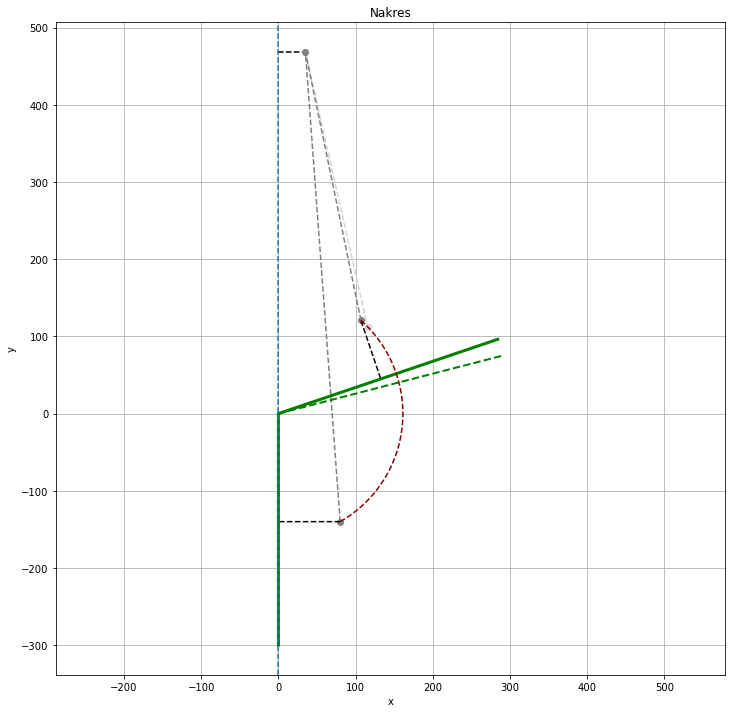

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))

# rameno uchycheni motoru
plt.plot([0,xm], [ym,ym], '--', color='black')

try:
    # pohon (zavreno, otevreno)
    plt.plot([xm, rp[0,0]], [ym, rp[0,1]], color='lightgray', marker='o', linestyle='--')
    plt.plot([p[0,0], xm, rpp[0,0]], [p[0,1], ym, rpp[0,1]], color='gray', marker='o', linestyle='--')

    # rameno otocneho bodu (zavreno, orevreno)
    plt.plot([p[0,0], p[2,0], 0, rpp[2,0], rpp[0,0]], [p[0,1], p[2,1], 0, rpp[2,1], rpp[0,1]], '--', color='black')

    # dvirka (zavreno, otevreno)
    plt.plot([0, rp[1,0]], [0, rp[1,1]], '--', linewidth=2, color='green')
    plt.plot([p[1,0], 0, rpp[1,0]], [p[1,1], 0, rpp[1,1]], linewidth=3, color='green')

    # draha otocneho bodu
    ang = np.linspace(np.arctan(rpp[0,1]/rpp[0,0]), np.arctan(-y/x), 100)
    xa = r * np.cos(ang)
    ya = r * np.sin(ang)
    
except:
    # pohon (zavreno, otevreno)
    plt.plot([p[0,0], xm, rp[0,0]], [p[0,1], ym, rp[0,1]], color='gray', marker='o', linestyle='--')

    # rameno otocneho bodu (zavreno, orevreno)
    plt.plot([p[0,0], p[2,0], 0, rp[2,0], rp[0,0]], [p[0,1], p[2,1], 0, rp[2,1], rp[0,1]], '--', color='black')

    # dvirka (zavreno, otevreno)
    plt.plot([p[1,0], 0, rp[1,0]], [p[1,1], 0, rp[1,1]], linewidth=3)

    # draha otocneho bodu
    ang = np.linspace(np.arctan(rp[0,1]/rp[0,0]), np.arctan(-y/x), 100)
    xa = r * np.cos(ang)
    ya = r * np.sin(ang)

plt.plot(xa, ya, '--', color='darkred')

plt.axvline(0, linestyle='--')
plt.axis('equal')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Nakres')

plt.show()